# Présentation des résultats en considérants différente configuration de contraintes dans notre programme linéaire

In [3]:
%load_ext autoreload
%autoreload 2

import gurobipy as gp
from gurobipy import GRB

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from first_model import Instance, Solution, Model
from utils import *

from copy import deepcopy


### #Compréhensions des unités de temps pour les taches et les jobs

| 1 unité | 10 minutes | 0.166 h |
|:-------- |:----------:| --------:|
| 42 unités | 420 minutes | 7 h |


| Unité | Job court | Job moyen | Job long |
|:-------- |:--------:|:----------:| --------:|
|heure/min| 30 min - 1h30 | 1h30 - 3h | 3h - 7h |
|unités|  3 - 9  | 9 - 18  | 18 - 42  |

- small job peut avoir soit :
    - 3 opérations de 30 min 
    - 9 opérations de 10 min

- medium job peut avoir soit :
    - 3 opérations de 1h
    - 6 opérations de 30 min 
    - 8 opérations de 10 min

- long job peut avoir soit :
    - 5 opérations de 1h 
    - 20 opération de 15 min

In [4]:
TIME_DAY = 42 # 42 unités de temps = 1 journée de travail soit 7h

In [5]:
time_type_of_jobs = {
    "small": (3, 9),
    "medium": (9, 18),
    "long": (18, 42)
}

In [6]:
# Voir si ajout un métier ou on ne peut pas apprendre ni collaboration car fait avec un cobot par exemple, mais demande charge cofgnitif
# nb task peut etre str ou int directement dans le config, si str alors on calcule en fonction du nb de jobs et du nb d'opérations max, sinon on prend la valeur donnée
# faire instance avce tache courte level faible et tache longue level élevé
# une tache peut refuser qu'un worker sans level la fasse car trop critique ou bien c'est au niveau du job que c'est trop critique ?

In [7]:
seed = np.random.randint(1, 1000) # pour générer un nombre aléatoire entre 1 et 1000 (inclus)
print(f"seed : {seed}")
config_instance = {
    "seed": seed,

    "nb_jobs": 7,
    "nb_workers": 4,
    "nb_professions": 4,
    "proportion_tasks_per_profession": [0.2, 0.3, 0.3, 0.2],
    "max_nb_operations": 6,
    "nb_tasks" : "lower", # "lower", "medium", "high"

    # "proportion_jobs": [0.3, 0.4, 0.3], # [small_jobs, medium_jobs, long_jobs]

    "proportion_tasks_without_collaborative_work": 0.2,
    "proportion_tasks_level_required": 0.1,

    "proportion_tasks_times" : [0.3, 0.4, 0.3], # [small_tasks (30 unités), medium_tasks (), long_tasks]
    "time_type_of_jobs" : time_type_of_jobs,
    "proportion_tasks_levels":[ 0.1, 0.3, 0.5, 0.1], # [level 1, level 2, level 3, level 4]

    "proportion_workers_levels":[ 0.2, 0.5, 0.2, 0.1], # [level 1, level 2, level 3, level 4]

    "at_least_a_worker_have_competence_for_each_profession": False
}

seed : 516


In [7]:
instance = Instance()
instance.from_config(config_instance)

set
[{0, 3, 5, 6, 7, 11, 17, 18, 19, 22, 29, 30, 34, 35, 38, 39, 40, 43, 45}, {1, 33, 4, 37, 8, 9, 10, 41, 12, 13, 20, 21, 23, 25}, {32, 2, 36, 42, 44, 14, 15, 16, 24, 26, 27, 28, 31}]


NB: Faire un set pour savoir chaque job, a quel type de job il a appartient (small, medium, long)

### #Visualisation de l'instance avant le scheduling

In [8]:
print(instance)


 ===== Start of Instance: =====
Number of jobs: 7
Number of professions: 4
Number of tasks per profession: [ 9 13 13  9]
Max number of operations per Jobs: 6
Total number of tasks: 46
Total number of workers: 4
Task to profession mapping:
{0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 14: 1, 15: 1, 16: 1, 17: 1, 18: 1, 19: 1, 20: 1, 21: 1, 22: 2, 23: 2, 24: 2, 25: 2, 26: 2, 27: 2, 28: 2, 29: 2, 30: 2, 31: 2, 32: 2, 33: 2, 34: 2, 35: 3, 36: 3, 37: 3, 38: 3, 39: 3, 40: 3, 41: 3, 42: 3, 43: 3, 44: 0, 45: 0}
Worker levels: shape=(4, 4)
 [[1 2 2 2]
 [3 1 4 2]
 [3 2 2 3]
 [4 2 1 3]]
Job difficulties: shape= (7,)
[3 3 3 3 3 3 3]
Job resale prices: shape= (7,)
[ 89.90751805  65.39810366  67.49631822  85.71047979  67.62260895
 115.32909799  49.67940836]
Task difficulties: shape= (46,)
[2 1 3 4 1 3 3 3 1 3 3 3 2 2 2 3 2 3 1 2 3 2 1 2 3 3 2 3 1 3 3 3 3 3 3 3 2
 2 2 3 2 2 3 3 3 3]
Task processing times: shape= (46, 3)
[[ 2.74421304  4.19537321  2.12964535

Job 1 is a medium job : time = 17.97
Job 2 is a small job : time = 8.01
Job 3 is a medium job : time = 16.73
Job 4 is a long job : time = 19.87
Job 5 is a long job : time = 18.59
Job 6 is a medium job : time = 13.75
Job 7 is a small job : time = 6.83
ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red'}


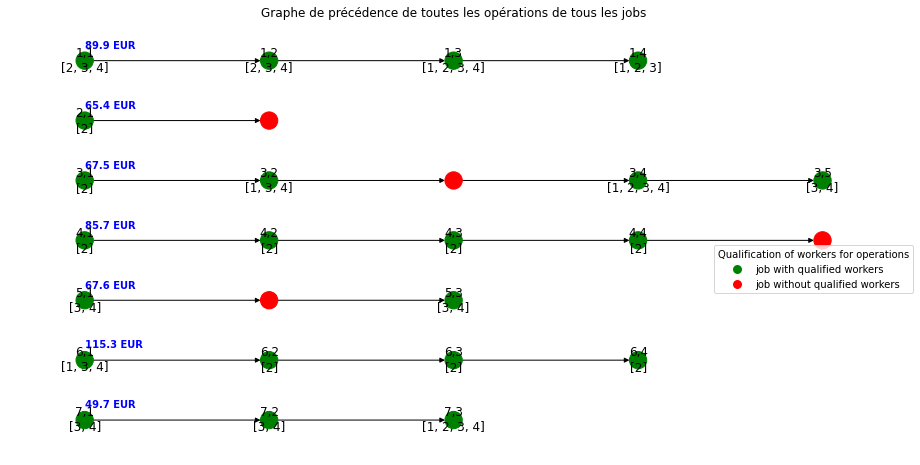

In [9]:
job_times = instance.time_each_job_alone(verbose=False)
for i in range(len(instance.jobs_struct)):
    if job_times[i] <= time_type_of_jobs["small"][1]:
        print(f"Job {i+1} is a small job : time = {job_times[i]:.2f}")
    elif job_times[i] <= time_type_of_jobs["medium"][1]: 
        print(f"Job {i+1} is a medium job : time = {job_times[i]:.2f}")
    elif job_times[i] <= time_type_of_jobs["long"][1]: 
        print(f"Job {i+1} is a long job : time = {job_times[i]:.2f}")
# print(instance)
visualization_before_scheduling(instance) # en rouge les opérations des job pour lesquelles il n'y a pas de worker qualifié

ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


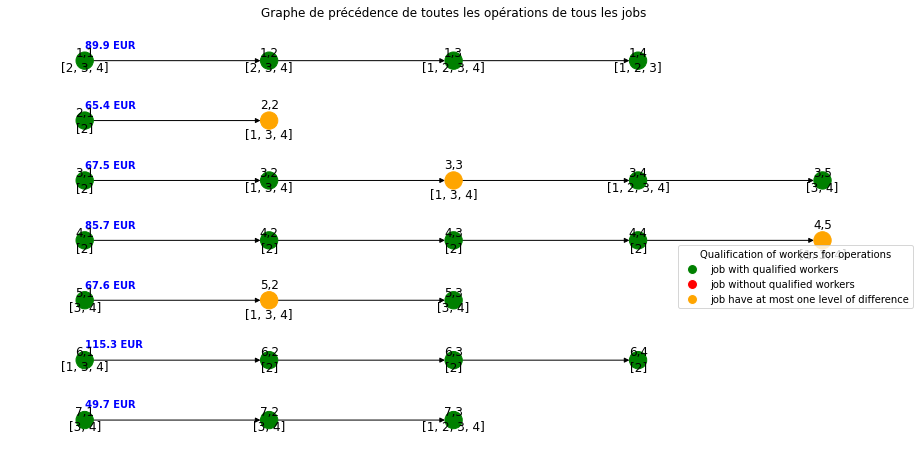

In [10]:
visualization_before_scheduling(instance, not_qualified=True) # en orange les opérations des job pour lesquelles il n'y a pas de worker qualifié mais au moins un worker avec un niveau de compétence à 1 de différence

In [11]:
print(f"temps total des jobs en mode alone : {instance.sum_of_job_alone():.2f} unités de temps")
TIME_DAY

temps total des jobs en mode alone : 101.74 unités de temps


42

# Slide 1
### #Sans autoriser les taches à être fait sans level requis

In [12]:
constraints_config = {"constrained_makespan": TIME_DAY/2}

In [13]:
model = Model(instance)
solution = model.solve(objective="benefit", constraints_config=constraints_config)


 ========== SOLVING MODEL ========== 
Set parameter Username
Academic license - for non-commercial use only - expires 2027-01-05
job with no skills desactived


TypeError: _constrained_makespan() missing 3 required positional arguments: 'penalty_makespan_job', 'job_done_before_limit', and 'C'

penalty_makespan= 2.2764501422292938
borne_sup_makespan= 21.0


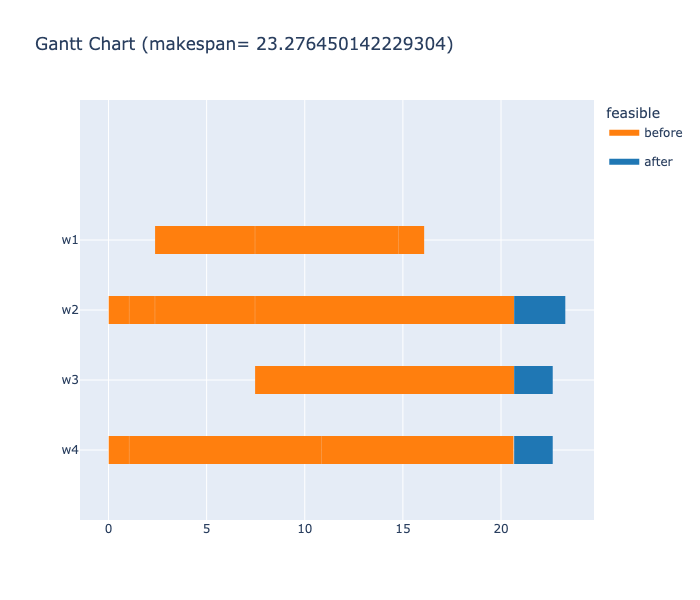

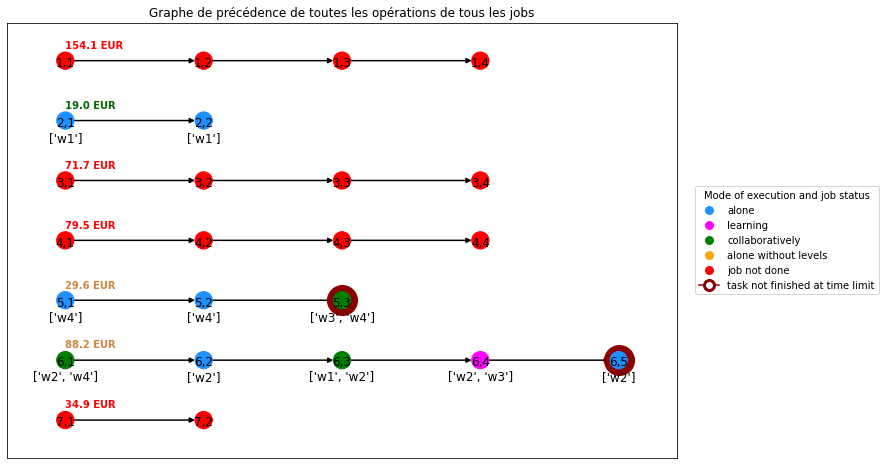

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,penalty_C_max,bool_penalty_C_max,Elementary task,Metier
0,w1,2.373337,7.460307,7.460307,5.096970,"(6,3)",J6,collaboratively,2,2,0,before,9.0,1.0
1,w1,7.470307,14.763923,14.763923,7.303616,"(2,1)",J2,alone,3,3,0,before,8.0,0.0
2,w1,14.773923,16.084337,16.084337,1.320414,"(2,2)",J2,alone,3,2,0,before,5.0,0.0
3,w2,0.010000,1.042923,1.042923,1.042923,"(6,1)",J6,collaboratively,3,2,0,before,10.0,1.0
4,w2,1.052923,2.363337,2.363337,1.320414,"(6,2)",J6,alone,2,2,0,before,5.0,0.0
5,w2,2.373337,7.460307,7.460307,5.096970,"(6,3)",J6,collaboratively,3,2,0,before,9.0,1.0
6,w2,7.470307,20.661283,20.661283,13.200976,"(6,4)",J6,learning (apprentice),2,3,0,before,4.0,0.0
7,w2,20.671283,23.276450,23.276450,2.615167,"(6,5)",J6,alone,3,3,2.27645,after,13.0,1.0
8,w3,7.470307,20.661283,20.661283,13.200976,"(6,4)",J6,learning (tutor),3,3,0,before,4.0,0.0
9,w3,20.671283,22.635623,22.635623,1.974340,"(5,3)",J5,collaboratively,1,1,1.635623,after,14.0,1.0


In [51]:
df = scheduling_to_df(solution, instance)
gantt_chart(df, render="notebook", color=1, separate_little=True)
visualization_after_scheduling(instance, solution, df)
df

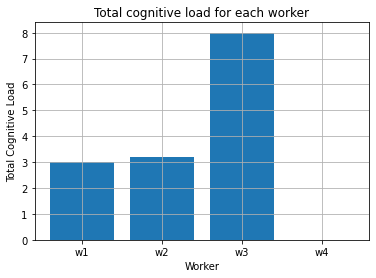

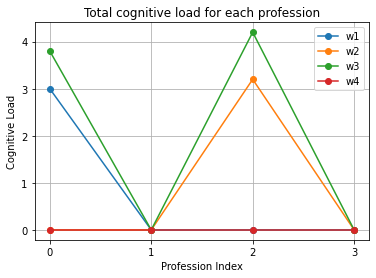

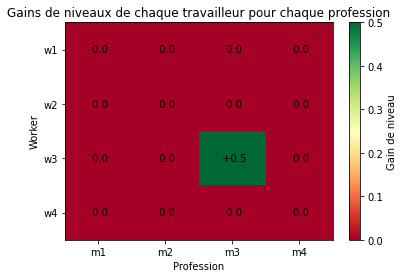

In [34]:
bars_cognitive_load_total(solution, instance)
plot_cognitive_load_total(solution, instance)
resume_levels_workers(solution, instance)

___

# Slide 2
### #En autorisant les taches à être fait sans level requis (au max 1 job ) 

In [52]:
constraints_config["job_with_no_skills"] = True

In [53]:
model = Model(instance)
solution = model.solve(objective="benefit", constraints_config=constraints_config)


 ========== SOLVING MODEL ========== 
job with no skills activated
limite MAKESPAN =  21.0
constrained makespan activated with limit = 21.0
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 21.0
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 170.5518629132941
nObjectives 1
nSolutions 3
et la -> 21.0


penalty_makespan= 42.82329569483932
borne_sup_makespan= 21.0


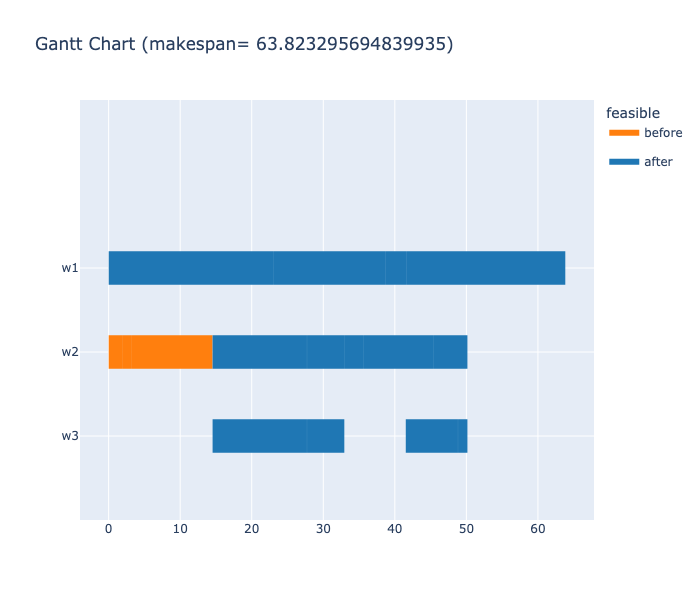

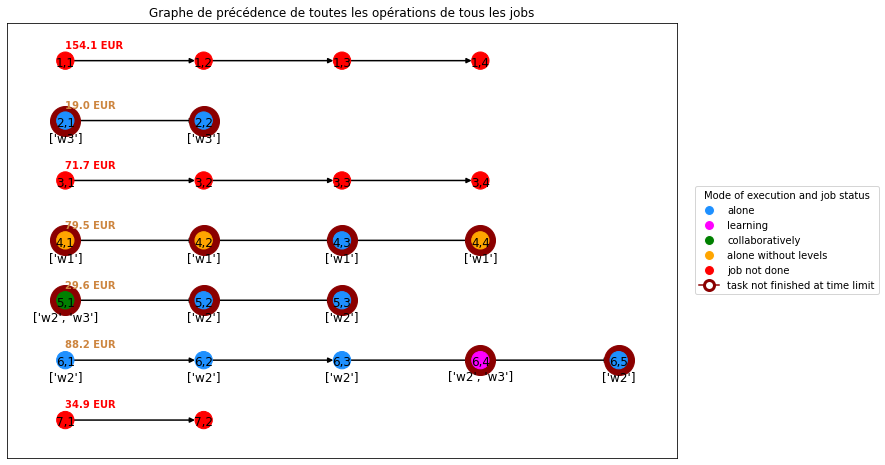

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,penalty_C_max,bool_penalty_C_max,Elementary task,Metier
0,w1,0.010000,22.976501,22.976501,22.976501,"(4,1)",J4,alone without levels,3,4,1.976501,after,42.0,3.0
1,w1,22.986501,38.709480,38.709480,15.732979,"(4,2)",J4,alone without levels,2,3,17.709480,after,27.0,2.0
2,w1,38.719480,41.577221,41.577221,2.867740,"(4,3)",J4,alone,2,2,20.577221,after,12.0,1.0
3,w1,41.587221,63.823296,63.823296,22.246075,"(4,4)",J4,alone without levels,2,3,42.823296,after,32.0,2.0
4,w2,0.010000,1.924782,1.924782,1.924782,"(6,1)",J6,alone,3,2,0.000000,before,10.0,1.0
5,w2,1.934782,3.245196,3.245196,1.320414,"(6,2)",J6,alone,2,2,0.000000,before,5.0,0.0
6,w2,3.255196,14.519174,14.519174,11.273977,"(6,3)",J6,alone,3,2,0.000000,before,9.0,1.0
7,w2,14.529174,27.720149,27.720149,13.200976,"(6,4)",J6,learning (apprentice),2,3,6.720149,after,4.0,0.0
8,w2,27.730149,32.939470,32.939470,5.219321,"(5,1)",J5,collaboratively,2,2,11.939470,after,7.0,0.0
9,w2,32.949470,35.554637,35.554637,2.615167,"(6,5)",J6,alone,3,3,14.554637,after,13.0,1.0


In [54]:
df = scheduling_to_df(solution, instance)
gantt_chart(df, render="notebook", color=1, separate_little=True)
visualization_after_scheduling(instance, solution, df)
df

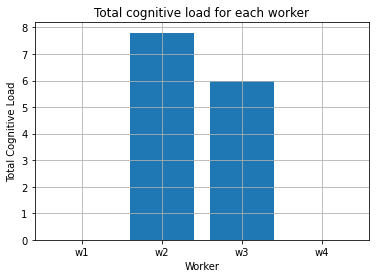

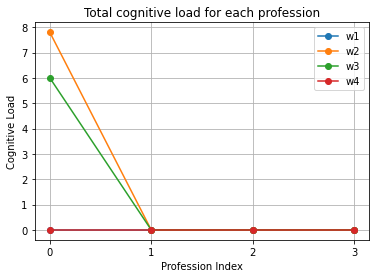

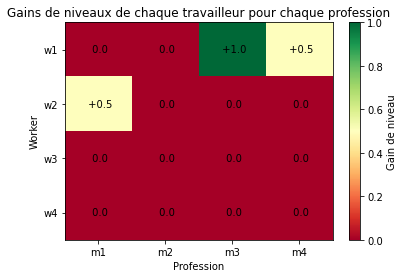

In [55]:
bars_cognitive_load_total(solution, instance)
plot_cognitive_load_total(solution, instance)
resume_levels_workers(solution, instance)

---

### lexicographiquement en minimisant le mental workload

In [56]:
constraints_config = {"constrained_makespan": TIME_DAY/2}
model = Model(instance)
solution = model.solve(objective="lexicographic", priority=[1, 0, 2], constraints_config=constraints_config)


 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  21.0
constrained makespan activated with limit = 21.0
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 21.0
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 45.28242709506961
nObjectives 3
nSolutions 4
et la -> 21.0


penalty_makespan= 3.389273121097432
borne_sup_makespan= 21.0


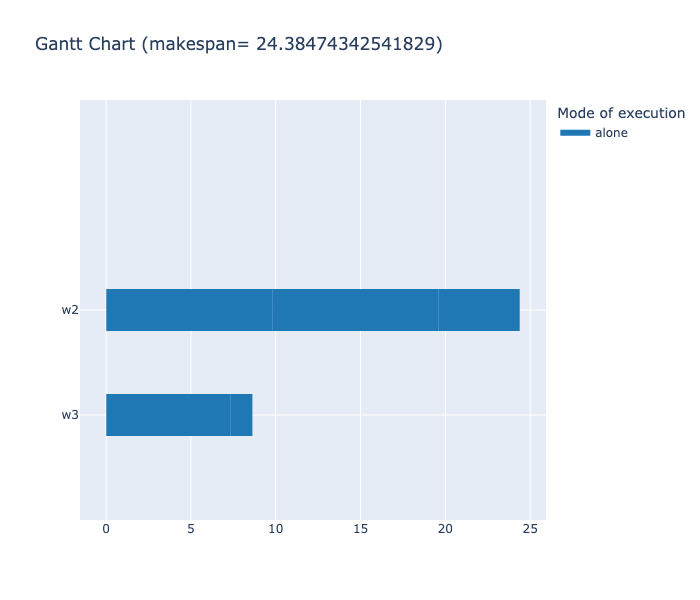

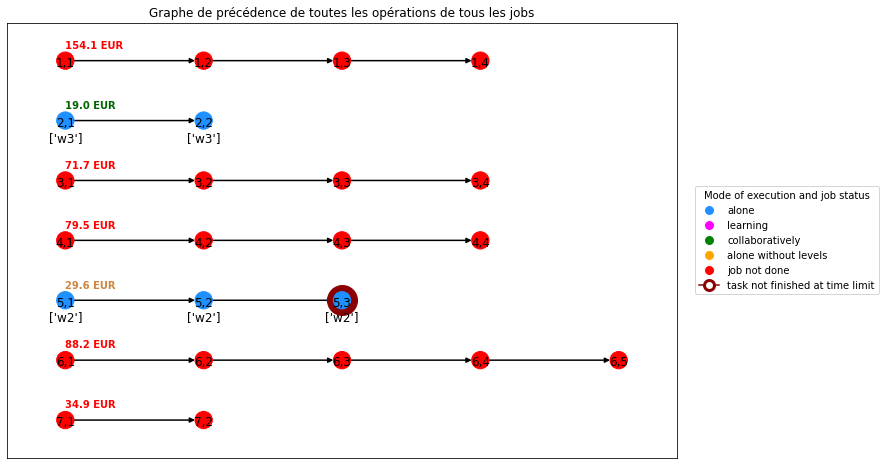

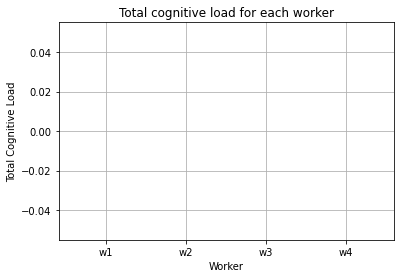

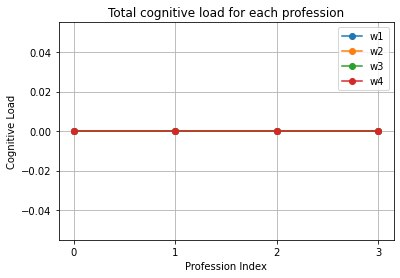

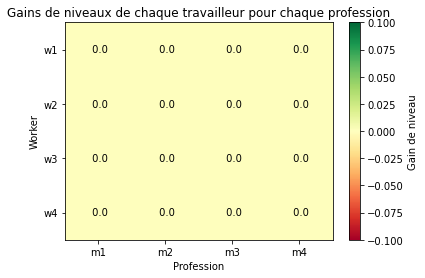

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,penalty_C_max,bool_penalty_C_max,Elementary task,Metier
0,w2,0.010000,9.795896,9.795896,9.795896,"(5,1)",J5,alone,2,2,0,before,7.0,0.0
1,w2,9.805896,19.591793,19.591793,9.795896,"(5,2)",J5,alone,2,2,0,before,7.0,0.0
2,w2,19.601793,24.384743,24.384743,4.792951,"(5,3)",J5,alone,3,1,3.384743,after,14.0,1.0
3,w3,0.010000,7.303616,7.303616,7.303616,"(2,1)",J2,alone,3,3,0,before,8.0,0.0
4,w3,7.313616,8.624030,8.624030,1.320414,"(2,2)",J2,alone,3,2,0,before,5.0,0.0


In [57]:
df = scheduling_to_df(solution, instance)
gantt_chart(df, render="notebook", color=3, separate_little=True)
visualization_after_scheduling(instance, solution, df)
# df

bars_cognitive_load_total(solution, instance)
plot_cognitive_load_total(solution, instance)
resume_levels_workers(solution, instance)
df

#### En autorisant les taches à être fait sans level requis (au max 1 job peut être fait sans level requis)

In [31]:
instance.sum_of_job_alone()

133.58734535318385

In [32]:
constraints_config = {
     "constrained_makespan": instance.sum_of_job_alone(),
     "job_with_no_skills" : True
}

In [33]:
model = Model(instance)
solution = model.solve(objective="benefit", constraints_config=constraints_config)


 ========== SOLVING MODEL ========== 
job with no skills activated
limite MAKESPAN =  133.58734535318385
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 134.1889801565956
nObjectives 1
nSolutions 2


penalty_makespan= 0.0


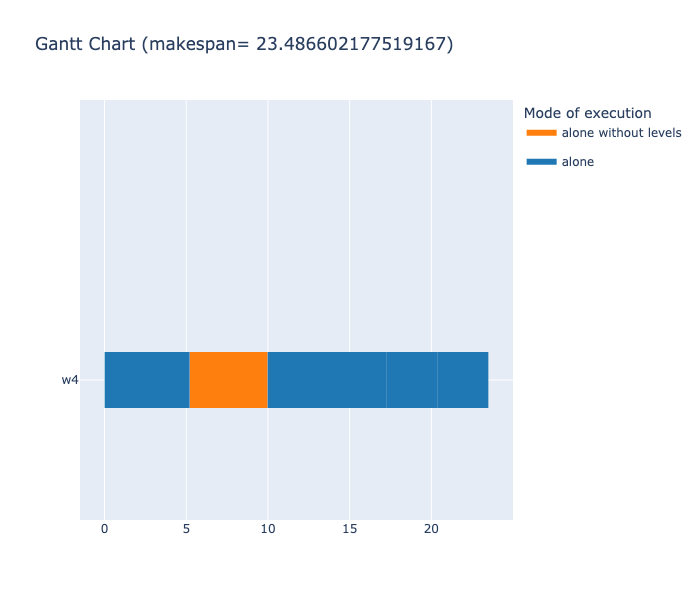

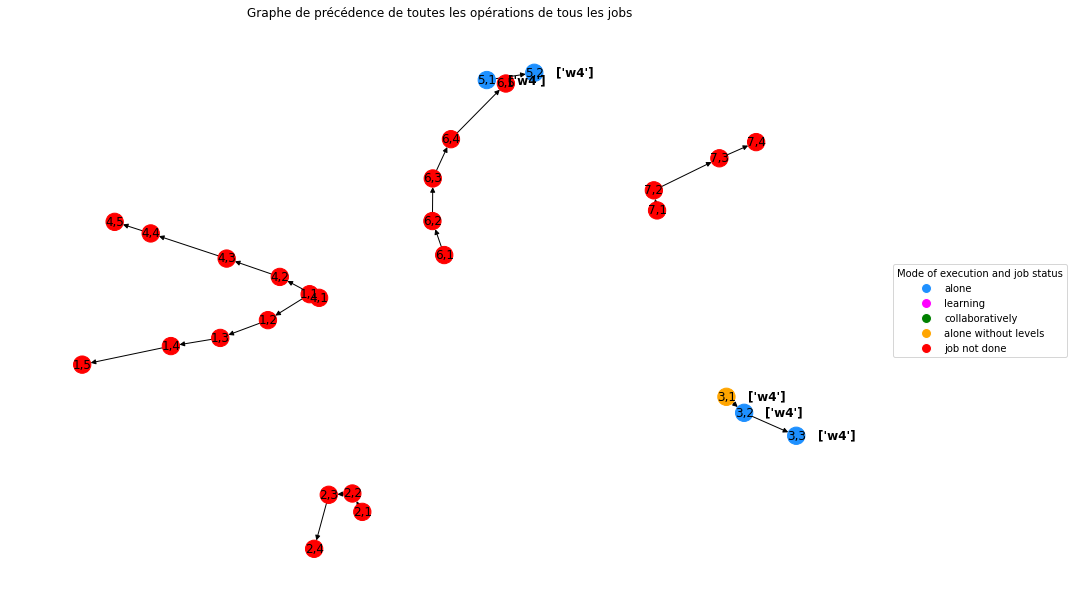

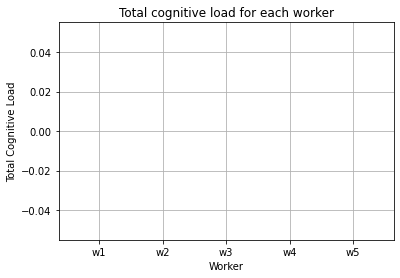

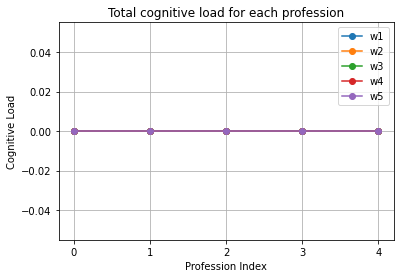

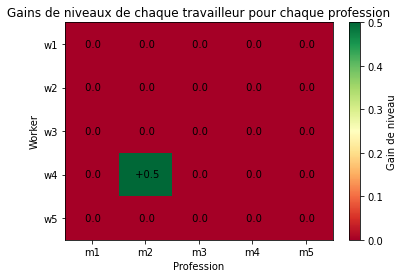

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,penalty_C_max,bool_penalty_C_max,Elementary task,Metier
0,w4,0.010000,5.205103,5.205103,5.205103,"(5,1)",J5,alone,3,3,0,0,10.0,1.0
1,w4,5.215103,9.975625,9.975625,4.770522,"(3,1)",J3,alone without levels,3,4,0,0,11.0,1.0
2,w4,9.985625,17.230967,17.230967,7.255343,"(3,2)",J3,alone,3,3,0,0,13.0,1.0
3,w4,17.240967,20.358785,20.358785,3.127817,"(3,3)",J3,alone,3,3,0,0,40.0,4.0
4,w4,20.368785,23.486602,23.486602,3.127817,"(5,2)",J5,alone,3,3,0,0,40.0,4.0


In [34]:
df = scheduling_to_df(solution, instance)
gantt_chart(df, render="notebook", color=3, separate_little=True)
visualization_after_scheduling(instance, solution, df)
# df

bars_cognitive_load_total(solution, instance)
plot_cognitive_load_total(solution, instance)
resume_levels_workers(solution, instance)
df

ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job without qualified workers but at most one level of difference': 'orange'}


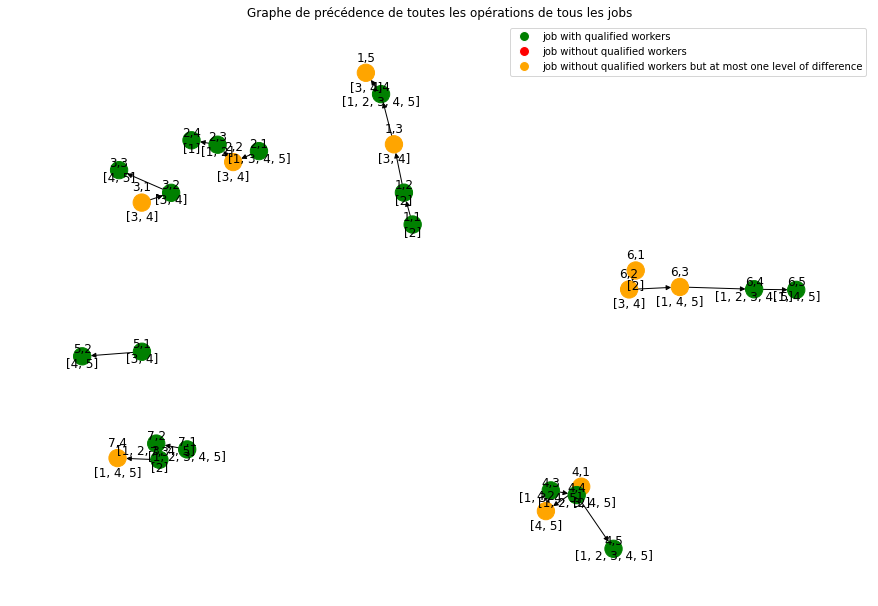

In [35]:
visualization_before_scheduling(instance, not_qualified=True)

# Slide 3
### #Avec Plus de workers compétents

In [60]:
config_instance["at_least_a_worker_have_competence_for_each_profession"] = True
instance = Instance()
instance.from_config(config_instance)

set
[{0, 1, 2, 3, 5, 6, 10, 12, 13, 15, 16, 23, 24, 28, 29, 33, 34, 37, 41}, {38, 40, 11, 45, 14, 17, 18, 21, 22, 26, 30}, {32, 35, 4, 36, 7, 8, 9, 39, 42, 43, 44, 19, 20, 25, 27, 31}]


ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


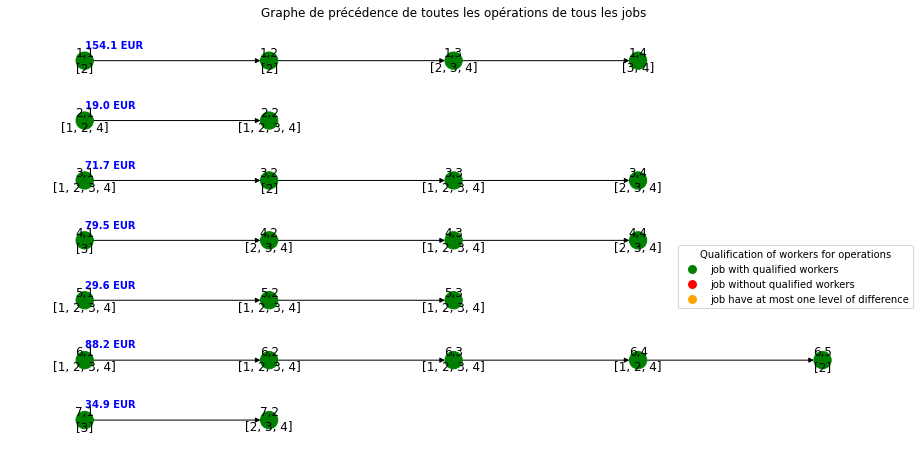

In [61]:
# print(instance)
visualization_before_scheduling(instance, not_qualified=True)

In [65]:
constraints_config = {
    "constrained_makespan": TIME_DAY/2,
    "job_with_no_skills" : False,
    "no_base_worker" : False
}

In [66]:
model = Model(instance)
solution = model.solve(objective="benefit", constraints_config=constraints_config)


 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  21.0
constrained makespan activated with limit = 21.0
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 21.0
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 301.15299175657236
nObjectives 1
nSolutions 8
et la -> 21.0


penalty_makespan= 21.861422026572125
borne_sup_makespan= 21.0


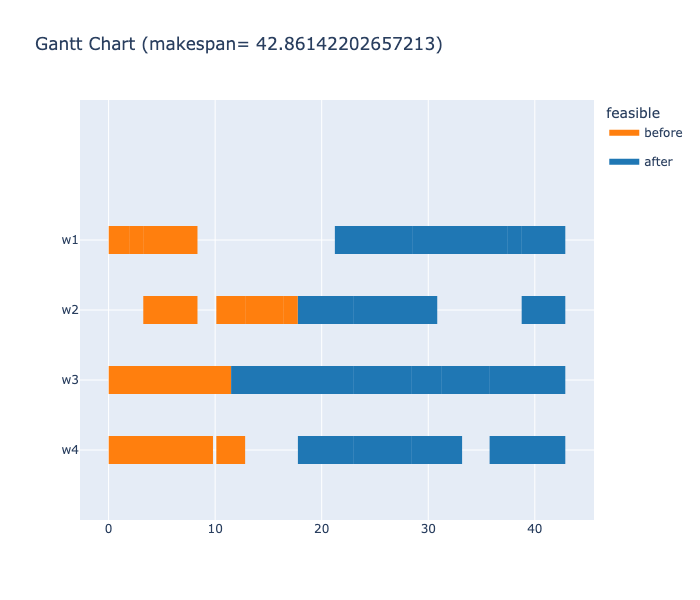

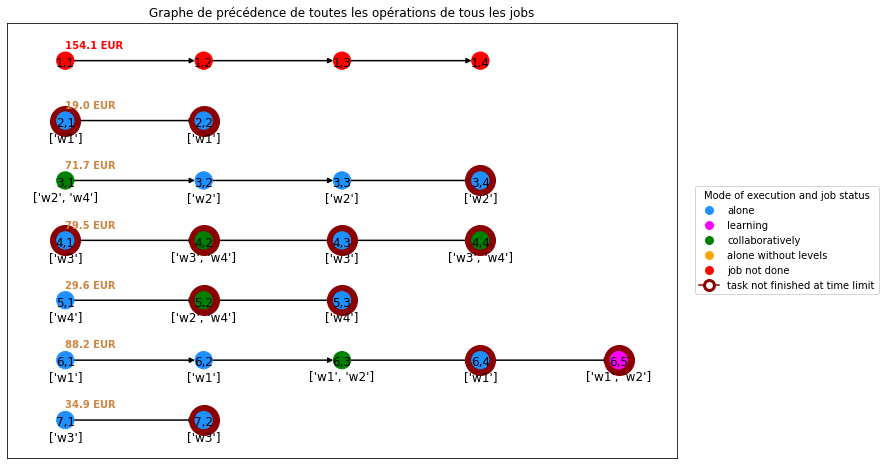

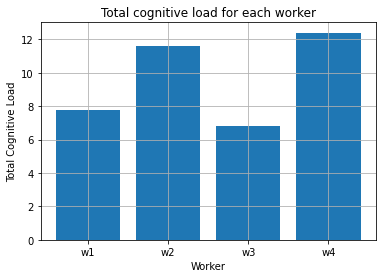

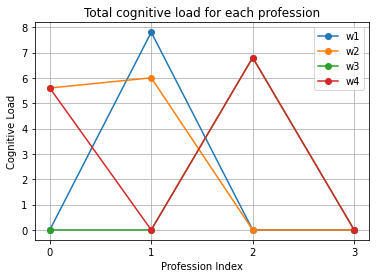

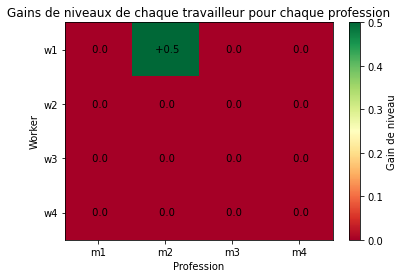

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,penalty_C_max,bool_penalty_C_max,Elementary task,Metier
0,w1,0.010000,1.924782,1.924782,1.924782,"(6,1)",J6,alone,2,2,0,before,10.0,1.0
1,w1,1.934782,3.245196,3.245196,1.320414,"(6,2)",J6,alone,4,2,0,before,5.0,0.0
2,w1,3.255196,8.342166,8.342166,5.096970,"(6,3)",J6,collaboratively,2,2,0,before,9.0,1.0
3,w1,21.235895,28.529511,28.529511,7.303616,"(2,1)",J2,alone,4,3,7.529511,after,8.0,0.0
4,w1,28.539511,37.437357,37.437357,8.907846,"(6,4)",J6,alone,4,3,16.437357,after,4.0,0.0
5,w1,37.447357,38.757771,38.757771,1.320414,"(2,2)",J2,alone,4,2,17.757771,after,5.0,0.0
6,w1,38.767771,42.861422,42.861422,4.103651,"(6,5)",J6,learning (apprentice),2,3,21.861422,after,13.0,1.0
7,w2,3.255196,8.342166,8.342166,5.096970,"(6,3)",J6,collaboratively,3,2,0,before,9.0,1.0
8,w2,10.112094,12.813921,12.813921,2.711827,"(3,1)",J3,collaboratively,3,2,0,before,45.0,0.0
9,w2,12.823921,16.436766,16.436766,3.622845,"(3,2)",J3,alone,4,4,0,before,33.0,2.0


In [67]:
df = scheduling_to_df(solution, instance)
gantt_chart(df, render="notebook", color=1, separate_little=True)
visualization_after_scheduling(instance, solution, df)
# df

bars_cognitive_load_total(solution, instance)
plot_cognitive_load_total(solution, instance)
resume_levels_workers(solution, instance)
df

---

# Slide 4
### $\epsilon$-contraintes

ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


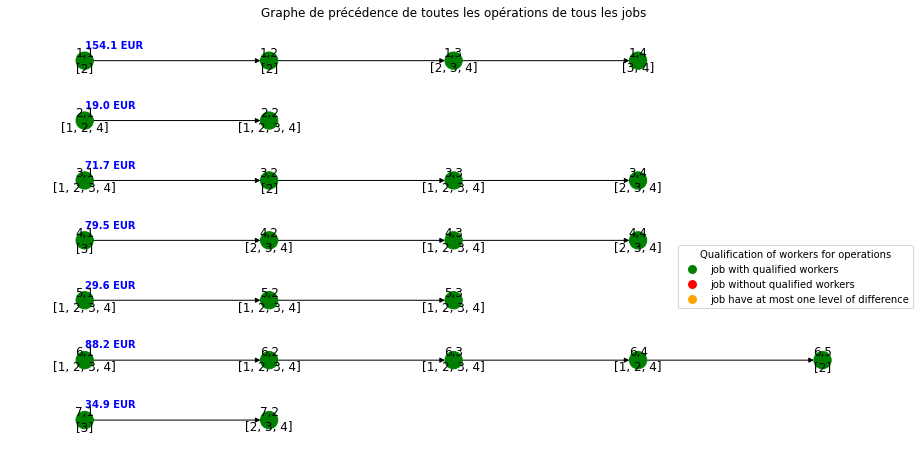

In [69]:
# print(instance)
visualization_before_scheduling(instance, not_qualified=True)

In [70]:
model = Model(instance)
x, s = model.epsilon_contraintes(constraints_config=constraints_config, verbose=False)


 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  21.0
constrained makespan activated with limit = 21.0
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 21.0
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 301.12287542717917
nObjectives 3
nSolutions 10
et la -> 21.0

 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  21.0
constrained makespan activated with limit = 21.0
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 21.0
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 301.12287542717917
nObjectives 3
nSolutions 10
et la -> 21.0

 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  21.0
constrained makespan activated with limit = 21.0
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 21.0
Set parameter Sol

nombre de solution trouvées:  14
nombre de solution uniques:  14


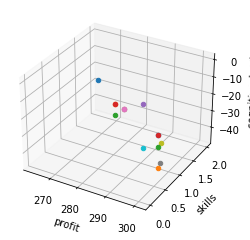

In [71]:
print("nombre de solution trouvées: ", len(x))
x_without_duplicate = np.unique(np.round(x, 5), axis=0)
print("nombre de solution uniques: ", len(x_without_duplicate))

plt.figure("Exemple 3D")
axes = plt.axes(projection="3d")
axes.set_xlabel("profit")
axes.set_ylabel("skills")
axes.set_zlabel("- cognitive_load")

for i in range(len(x_without_duplicate)):
    axes.scatter(x_without_duplicate[i,0], x_without_duplicate[i,1], x_without_duplicate[i,2], marker="o")
plt.show()

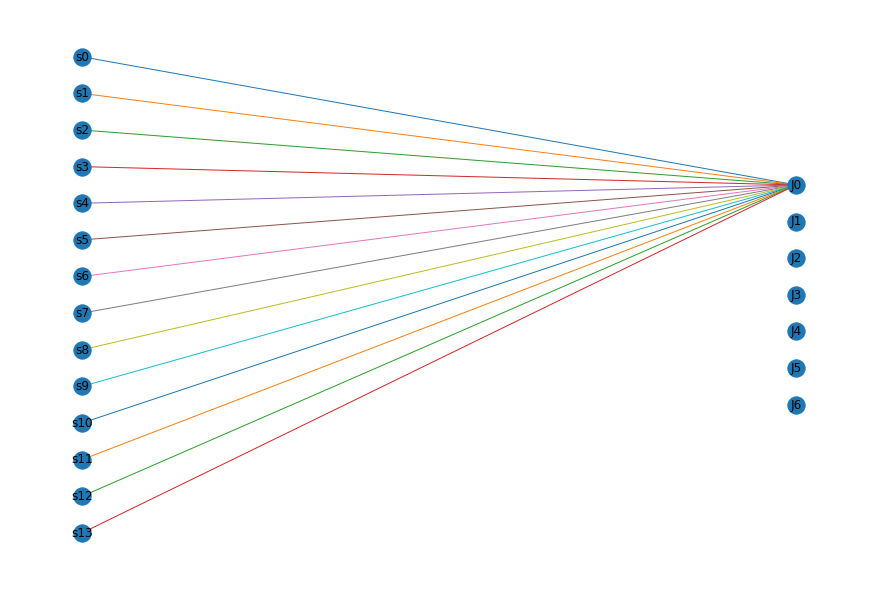

In [75]:
visualization_list_of_solutions(instance, s, doing=False)

- aucune solution ne fait le job 0

In [93]:
def df_to_job_penalty_time(df):
    df_grouped = (
        df[["Job", "penalty_C_max"]]
        .groupby("Job")
        .agg("sum")
    ).reset_index()
    return df_grouped

In [94]:
print(df_to_job_penalty_time(df))

  Job  penalty_C_max
0  J2      25.287283
1  J3       9.842991
2  J4      70.715745
3  J5      16.128839
4  J6      60.160201
5  J7      14.748145


In [ ]:
real_resal_price = [ 0 for _ in range(len(s))]
for i in range(len(s)):

    df = scheduling_to_df(s[i], instance)
    df_grouped = df_to_job_penalty_time(df)
    print(df_grouped)
    print((len(s[i].job_done)))

    resale_price = 0
    for j in range(len(df_grouped)):
        job_j = df_grouped.loc[j]["Job"][1]
        print(f"job {job_j} : penalty = {df_grouped.loc[j]['penalty_C_max']}")
        if s[i].job_done[j] == 1 and df_grouped.loc[j]["penalty_C_max"] == 0:
            resale_price += instance.resale_price_jobs[j]
    real_resal_price[i] = resale_price

real_resal_price

penalty_makespan= 21.891538355965324
borne_sup_makespan= 21.0
  Job  penalty_C_max
0  J2      34.358258
1  J3       5.111656
2  J4      45.068783
3  J5      46.292818
4  J6      20.857632
5  J7      29.304541
7


KeyError: 6

---

# #Maximiser le nombre de job fini avant et après TIME_LIMITE multiplié par coefficient de prix de revente

- constraints_config (déja ajouté et bien pratique)
- objective_config (à ajouter pour simplifier la modification de l'objectif dans le code)

In [18]:
seed = np.random.randint(1, 1000) # pour générer un nombre aléatoire entre 1 et 1000 (inclus)
print(f"seed : {seed}")
config_instance = {
    "seed": seed,

    "nb_jobs": 7,
    "nb_workers": 4,
    "nb_professions": 4,
    "proportion_tasks_per_profession": [0.2, 0.3, 0.3, 0.2],
    "max_nb_operations": 6,
    "nb_tasks" : "lower", # "lower", "medium", "high"

    # "proportion_jobs": [0.3, 0.4, 0.3], # [small_jobs, medium_jobs, long_jobs]

    "proportion_tasks_without_collaborative_work": 0.2,
    "proportion_tasks_level_required": 0.1,

    "proportion_tasks_times" : [0.3, 0.4, 0.3], # [small_tasks (30 unités), medium_tasks (), long_tasks]
    "time_type_of_jobs" : time_type_of_jobs,
    "proportion_tasks_levels":[ 0.1, 0.3, 0.5, 0.1], # [level 1, level 2, level 3, level 4]

    "proportion_workers_levels":[ 0.2, 0.5, 0.2, 0.1], # [level 1, level 2, level 3, level 4]

    "at_least_a_worker_have_competence_for_each_profession": True
}

seed : 410


In [20]:
instance = Instance()
instance.from_config(config_instance)

set
[{32, 1, 33, 35, 5, 6, 13, 14, 15, 20, 22, 25, 26, 29}, {3, 10, 12, 16, 17, 18, 19, 21, 24, 27, 28, 36, 37, 38, 40, 41, 43, 44, 45}, {0, 2, 34, 4, 7, 8, 9, 39, 11, 42, 23, 30, 31}]


ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


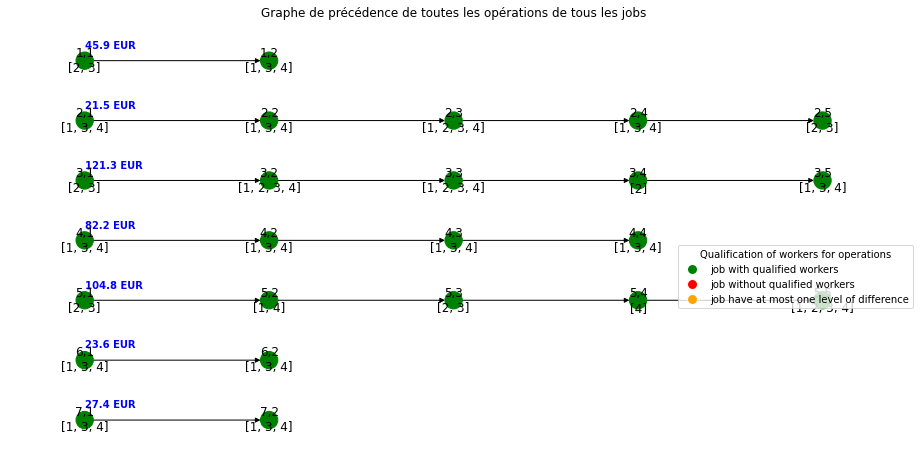

In [62]:
visualization_before_scheduling(instance, not_qualified=True)

### A) max profit des jobs done même si fini après limite de temps accordé 

```python
benefit_obj = gp.quicksum(self.instance.resale_price_jobs[i] * job_done[i] for i in range(self.instance.nb_jobs))
```

```python
m.setObjective(benefit_obj - penalty_levels_obj - penalty_makespan, GRB.MAXIMIZE)
```

In [63]:
model = Model(instance)
s = model.solve(objective="benefit", constraints_config=constraints_config, benefit_in_time=False)


 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  21.0
constrained makespan activated with limit = 21.0
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 21.0
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 398.8685979678442
nObjectives 1
nSolutions 10
et la -> 21.0


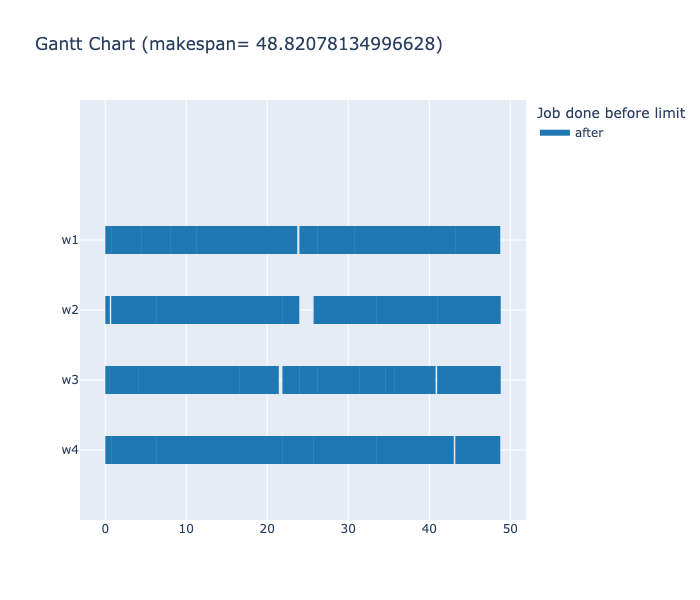

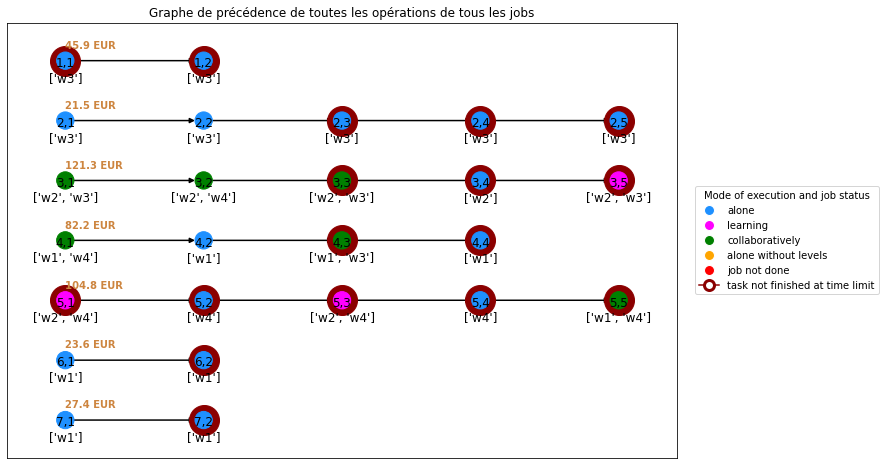

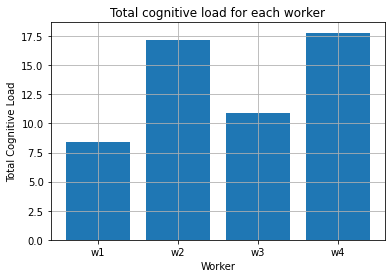

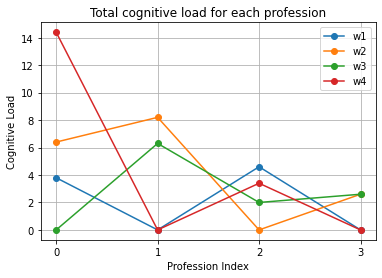

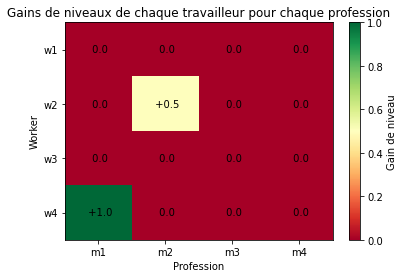

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,penalty_C_max,bool_penalty_C_max,Job_done_before_limit,Elementary task,Metier
0,w1,0.010000,0.732394,0.732394,0.732394,"(4,1)",J4,collaboratively,4,3,0,before,after,29.0,2.0
1,w1,0.742394,4.513695,4.513695,3.781301,"(6,1)",J6,alone,3,2,0,before,after,17.0,1.0
2,w1,4.523695,8.063184,8.063184,3.549490,"(7,1)",J7,alone,4,3,0,before,after,25.0,2.0
3,w1,8.073184,11.284065,11.284065,3.220881,"(4,2)",J4,alone,3,2,0,before,after,15.0,1.0
4,w1,11.294065,23.706732,23.706732,12.422668,"(6,2)",J6,alone,3,2,2.706732,after,after,11.0,1.0
5,w1,23.969185,26.250380,26.250380,2.291194,"(4,3)",J4,collaboratively,4,2,5.25038,after,after,27.0,2.0
6,w1,26.260380,30.784157,30.784157,4.533777,"(7,2)",J7,alone,3,2,9.784157,after,after,10.0,1.0
7,w1,30.794157,43.206825,43.206825,12.422668,"(4,4)",J4,alone,3,2,22.206825,after,after,11.0,1.0
8,w1,43.216825,48.765268,48.765268,5.558444,"(5,5)",J5,collaboratively,1,1,27.765268,after,after,4.0,0.0
9,w2,0.010000,0.562280,0.562280,0.562280,"(3,1)",J3,collaboratively,4,3,0,before,after,35.0,3.0


In [65]:
df = scheduling_to_df(s, instance)
gantt_chart(df, render="notebook", color=4, separate_little=True)
visualization_after_scheduling(instance, s, df)
# df

bars_cognitive_load_total(s, instance)
plot_cognitive_load_total(s, instance)
resume_levels_workers(s, instance)
df

### B) max profit des jobs done fini avant limite de temps accordé seulement 

### - B) En stand BY -

```python
benefit_obj_in_time = gp.quicksum(self.instance.resale_price_jobs[i] * job_done_before_limit[i] for i in range(self.instance.nb_jobs))
```

```python
m.setObjective(benefit_obj_in_time - penalty_levels_obj - penalty_makespan_job_OBJ, GRB.MAXIMIZE)
```

In [255]:
model = Model(instance)
s = model.solve(objective="benefit", constraints_config=constraints_config, benefit_in_time=True)


 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  21.0
constrained makespan activated with limit = 21.0
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 21.0
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 79.78320564162219
nObjectives 1
nSolutions 3
et la -> 21.0


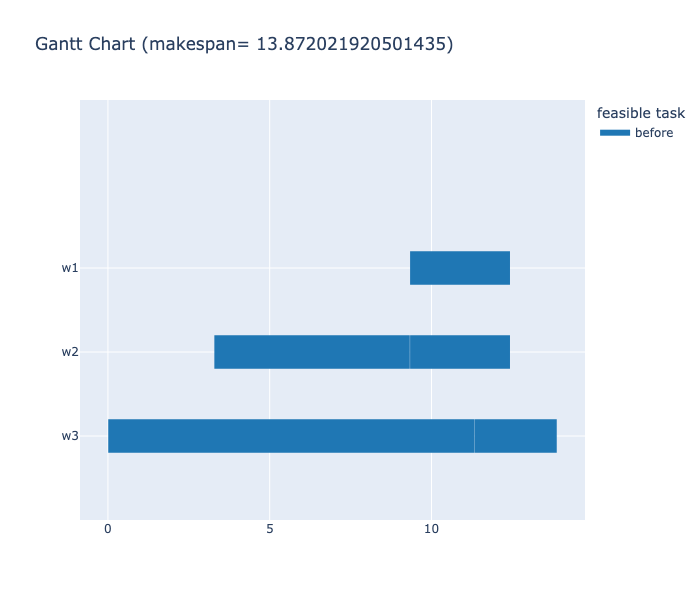

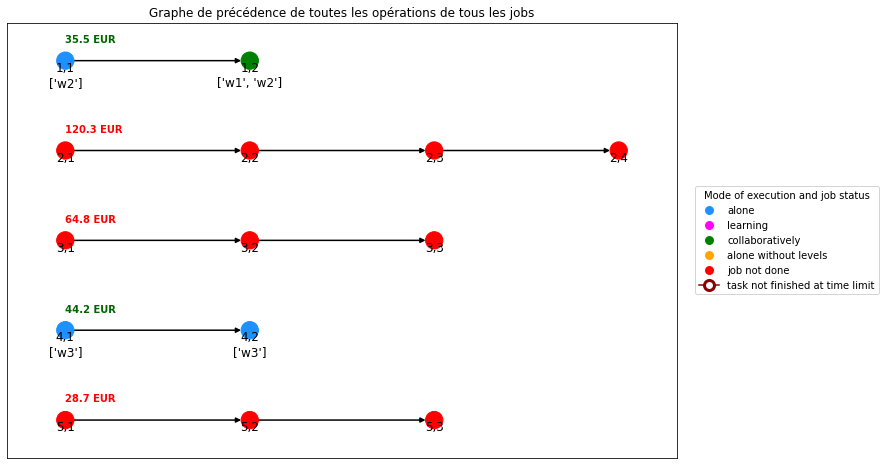

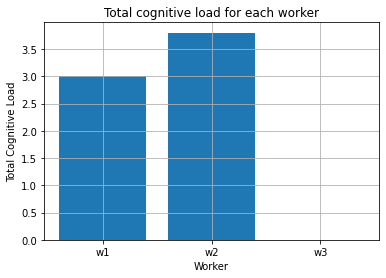

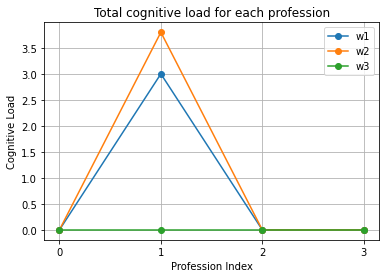

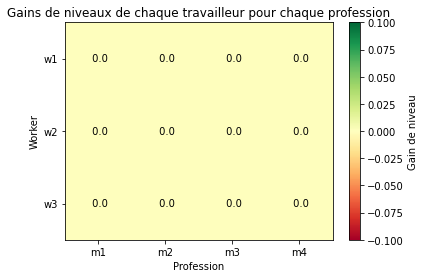

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,penalty_C_max,bool_penalty_C_max,Job_done_before_limit,Elementary task,Metier
0,w1,9.339421,12.426394,12.426394,3.096973,"(1,2)",J1,collaboratively,2,1,0,before,before,10.0,1.0
1,w2,3.289309,9.329421,9.329421,6.050112,"(1,1)",J1,alone,4,3,0,before,before,2.0,0.0
2,w2,9.339421,12.426394,12.426394,3.096973,"(1,2)",J1,collaboratively,1,1,0,before,before,10.0,1.0
3,w3,0.010000,11.334432,11.334432,11.334432,"(4,1)",J4,alone,2,2,0,before,before,7.0,1.0
4,w3,11.344432,13.872022,13.872022,2.537590,"(4,2)",J4,alone,2,2,0,before,before,16.0,2.0


In [256]:
df = scheduling_to_df(s, instance)
gantt_chart(df, render="notebook", color=1, separate_little=True)
visualization_after_scheduling(instance, s, df)
# df

bars_cognitive_load_total(s, instance)
plot_cognitive_load_total(s, instance)
resume_levels_workers(s, instance)
df

### C) max profit des jobs done fini avant et après limite de temps accordé

```python
benefit_obj_in_time = gp.quicksum(self.instance.resale_price_jobs[i] * job_done_before_limit[i] for i in range(self.instance.nb_jobs))
```

```python
m.setObjective(benefit_obj_in_time + benefit_obj - penalty_levels_obj - penalty_makespan_job_OBJ, GRB.MAXIMIZE)
```

In [66]:
model = Model(instance)
s = model.solve(objective="benefit", constraints_config=constraints_config, benefit_in_time=True)


 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  21.0
constrained makespan activated with limit = 21.0
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 21.0
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 537.1477033365335
nObjectives 1
nSolutions 10
et la -> 21.0


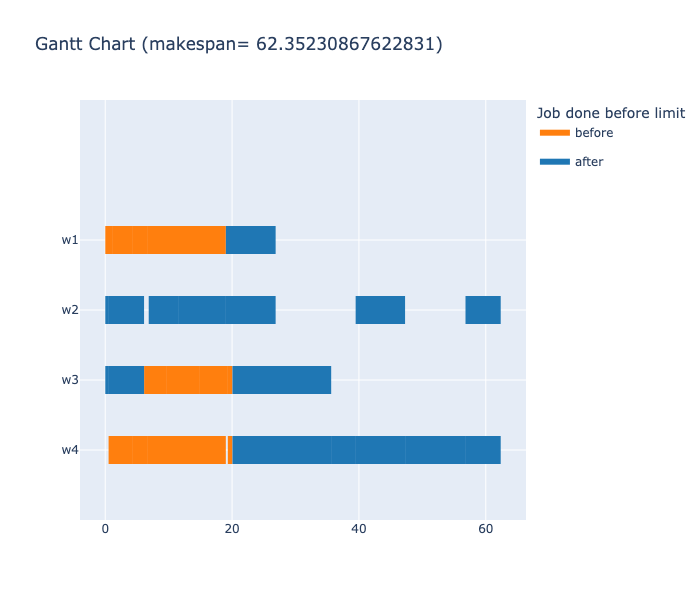

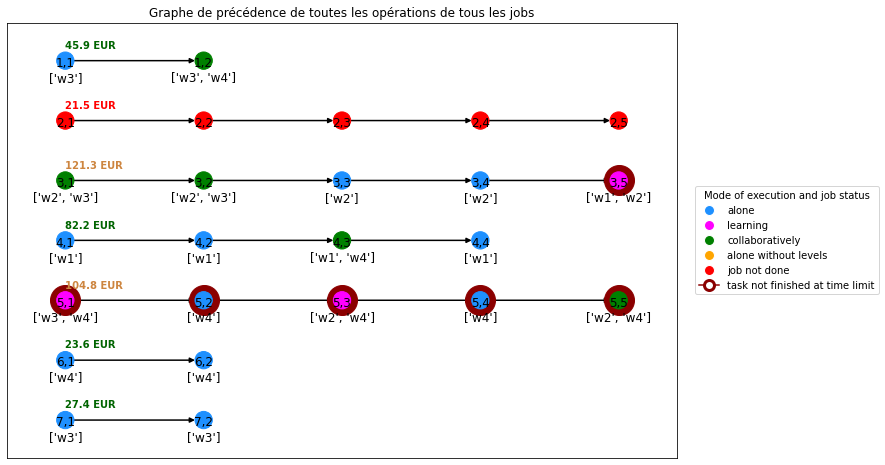

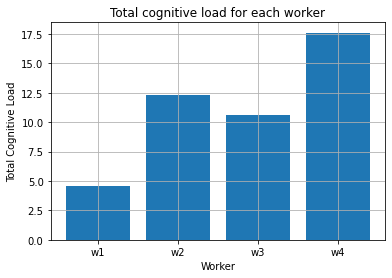

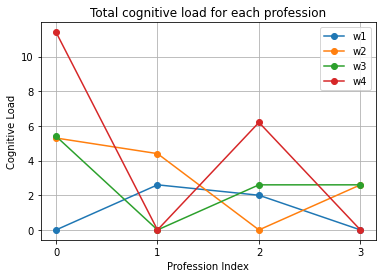

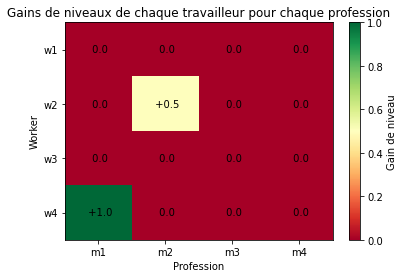

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,penalty_C_max,bool_penalty_C_max,Job_done_before_limit,Elementary task,Metier
0,w1,0.010000,1.078548,1.078548,1.078548,"(4,1)",J4,alone,4,3,0,before,before,29.0,2.0
1,w1,1.088548,4.299429,4.299429,3.220881,"(4,2)",J4,alone,3,2,0,before,before,15.0,1.0
2,w1,4.309429,6.590623,6.590623,2.291194,"(4,3)",J4,collaboratively,4,2,0,before,before,27.0,2.0
3,w1,6.600623,19.013291,19.013291,12.422668,"(4,4)",J4,alone,3,2,0,before,before,11.0,1.0
4,w1,19.023291,26.866043,26.866043,7.852752,"(3,5)",J3,learning (tutor),3,2,5.866043,after,after,21.0,1.0
5,w2,0.010000,0.562280,0.562280,0.562280,"(3,1)",J3,collaboratively,4,3,0,before,after,35.0,3.0
6,w2,0.572280,6.120724,6.120724,5.558444,"(3,2)",J3,collaboratively,4,1,0,before,after,4.0,0.0
7,w2,6.855757,11.559475,11.559475,4.713718,"(3,3)",J3,alone,1,1,0,before,after,12.0,1.0
8,w2,11.569475,19.013291,19.013291,7.453816,"(3,4)",J3,alone,4,4,0,before,after,2.0,0.0
9,w2,19.023291,26.866043,26.866043,7.852752,"(3,5)",J3,learning (apprentice),1,2,5.866043,after,after,21.0,1.0


In [68]:
df = scheduling_to_df(s, instance)
gantt_chart(df, render="notebook", color=4, separate_little=True)
visualization_after_scheduling(instance, s, df)
# df

bars_cognitive_load_total(s, instance)
plot_cognitive_load_total(s, instance)
resume_levels_workers(s, instance)
df

---

# #$\epsilon$-contraintes

#### ##Pour le profit maximisation des jobs finit avant la date limite et job finit, donc ceux finit avant compte double

In [34]:
seed = np.random.randint(1, 1000) # pour générer un nombre aléatoire entre 1 et 1000 (inclus)
print(f"seed : {seed}")
config_instance = {
    "seed": seed,

    "nb_jobs": 5,
    "nb_workers": 3,
    "nb_professions": 4,
    "proportion_tasks_per_profession": [0.2, 0.3, 0.3, 0.2],
    "max_nb_operations": 5,
    "nb_tasks" : "lower", # "lower", "medium", "high"

    # "proportion_jobs": [0.3, 0.4, 0.3], # [small_jobs, medium_jobs, long_jobs]

    "proportion_tasks_without_collaborative_work": 0.2,
    "proportion_tasks_level_required": 0.1,

    "proportion_tasks_times" : [0.3, 0.4, 0.3], # [small_tasks (30 unités), medium_tasks (), long_tasks]
    "time_type_of_jobs" : time_type_of_jobs,
    "proportion_tasks_levels":[ 0.1, 0.3, 0.5, 0.1], # [level 1, level 2, level 3, level 4]

    "proportion_workers_levels":[ 0.2, 0.4, 0.2, 0.2], # [level 1, level 2, level 3, level 4]

    "at_least_a_worker_have_competence_for_each_profession": False
}

seed : 799


In [35]:
instance = Instance()
instance.from_config(config_instance)

set
[{12, 13, 16, 18, 24}, {1, 2, 5, 9, 10, 11, 14, 15, 17, 22, 23, 25, 26}, {0, 3, 4, 6, 7, 8, 19, 20, 21}]


ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


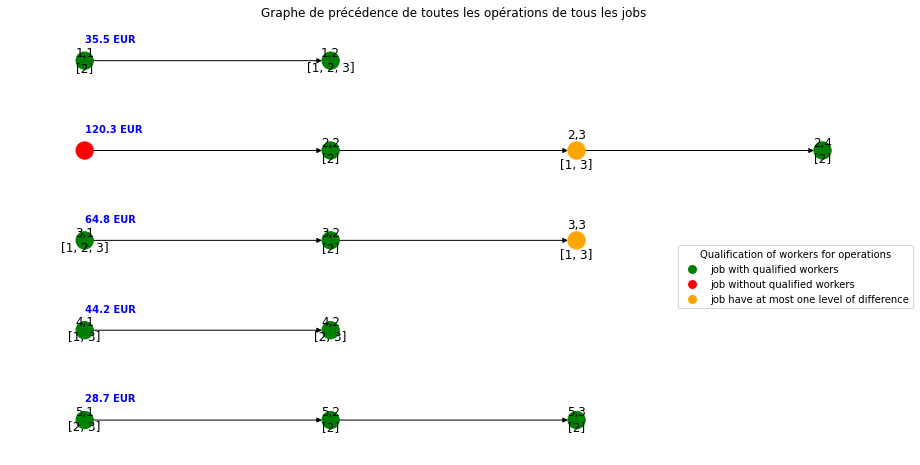

In [257]:
# print(instance)
visualization_before_scheduling(instance, not_qualified=True)

In [276]:
constraints_config = {
    "constrained_makespan": TIME_DAY/2,
    "job_with_no_skills" : False,
    "no_base_worker" : False
    }

In [277]:
model = Model(instance)
x, s = model.epsilon_contraintes(constraints_config=constraints_config, verbose=False, benefit_in_time=True)


 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  21.0
constrained makespan activated with limit = 21.0
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 21.0
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 79.78320564162219
nObjectives 3
nSolutions 7
et la -> 21.0

 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  21.0
constrained makespan activated with limit = 21.0
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 21.0
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 79.78320564162219
nObjectives 3
nSolutions 6
et la -> 21.0

 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  21.0
constrained makespan activated with limit = 21.0
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 21.0
Set parameter SolFile

In [320]:
df_x = pd.DataFrame(x, columns=["benefit", "skills", "cognitive_load"])
print("Nombre de solutions trouvées: ", len(x))
df_x

Nombre de solutions trouvées:  14


,benefit,skills,cognitive_load
0,79.783206,1.0,-13.7
1,79.783206,0.0,-0.0
2,35.549720,3.0,-42.5
3,35.549720,3.0,-42.5
4,79.783206,0.0,-0.0
5,79.783206,0.0,-0.0
6,79.783206,1.0,-14.4
7,79.783206,1.0,-20.4
8,79.783206,0.0,-6.8
9,79.783206,1.5,-34.2


In [321]:
df_x_prime = df_x.round(5).drop_duplicates(inplace=False)
print("nombre de solution uniques: ", len(df_x_prime))
df_x_prime

nombre de solution uniques:  9


,benefit,skills,cognitive_load
0,79.78321,1.0,-13.7
1,79.78321,0.0,-0.0
2,35.54972,3.0,-42.5
6,79.78321,1.0,-14.4
7,79.78321,1.0,-20.4
8,79.78321,0.0,-6.8
9,79.78321,1.5,-34.2
10,79.78321,1.5,-20.7
13,35.54972,3.0,-43.2


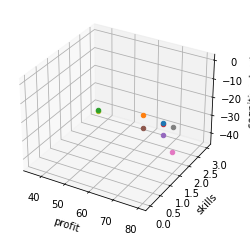

In [322]:
plt.figure("Exemple 3D")
axes = plt.axes(projection="3d")
axes.set_xlabel("profit")
axes.set_ylabel("skills")
axes.set_zlabel("- cognitive_load")

for i in range(len(df_x_prime)):
    axes.scatter(df_x_prime.iloc[i,0], df_x_prime.iloc[i,1], df_x_prime.iloc[i,2], marker="o")
plt.show()

In [323]:
x_not_dominated, _ = get_pareto_optimal(df_x_prime.to_numpy())
df_x_not_dominated = pd.DataFrame(x_not_dominated, columns=["benefit", "skills", "cognitive_load"])
df_x_not_dominated

,benefit,skills,cognitive_load
0,79.78321,1.0,-13.7
1,79.78321,0.0,-0.0
2,35.54972,3.0,-42.5
3,79.78321,1.5,-20.7


Faire correspondre les indices de df_x_not_dominated a ceux de df_x_prime pour retrouver les solutions correspondantes dans s

In [330]:
index_not_dominated = df_x_prime.reset_index().merge(df_x_not_dominated)['index'].tolist()
df_x_not_dominated.index = index_not_dominated
df_x_not_dominated

,benefit,skills,cognitive_load
0,79.78321,1.0,-13.7
1,79.78321,0.0,-0.0
2,35.54972,3.0,-42.5
10,79.78321,1.5,-20.7


In [331]:
ideal_point = np.array([max(x_not_dominated[:,0]), max(x_not_dominated[:,1]), max(x_not_dominated[:,2])])
print("ideal point : ", ideal_point)

ideal point :  [79.78321  3.      -0.     ]


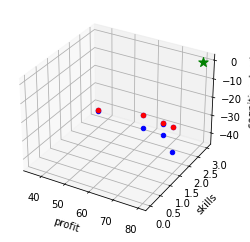

In [332]:
plt.figure("Exemple 3D")
axes = plt.axes(projection="3d")
axes.set_xlabel("profit")
axes.set_ylabel("skills")
axes.set_zlabel("- cognitive_load")

for i in range(len(df_x_prime)):
    axes.scatter(df_x_prime.iloc[i,0], df_x_prime.iloc[i,1], df_x_prime.iloc[i,2], marker="o", color="blue")
for i in range(len(df_x_not_dominated)):
    axes.scatter(df_x_not_dominated.iloc[i,0], df_x_not_dominated.iloc[i,1], df_x_not_dominated.iloc[i,2], marker="o", color="red")
axes.scatter(ideal_point[0], ideal_point[1], ideal_point[2], marker="*", color="green", s=100, label="ideal point")
plt.show()

solution 0
benefit           79.78321
skills             1.00000
cognitive_load   -13.70000
Name: 0, dtype: float64


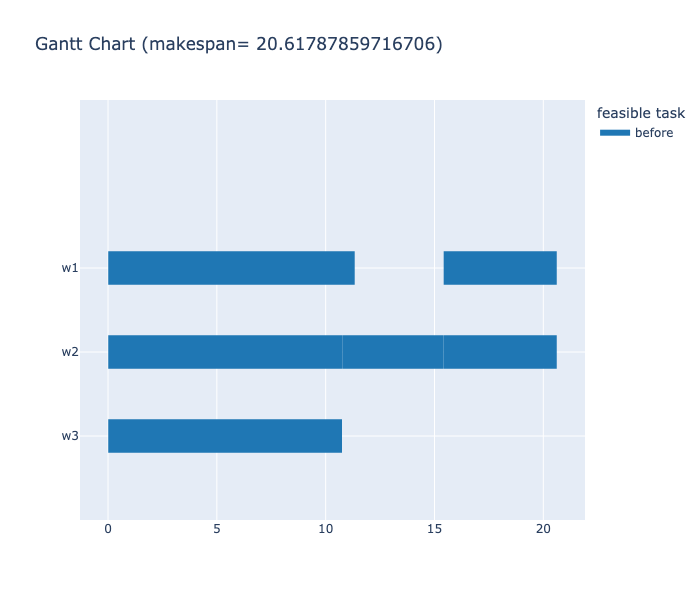

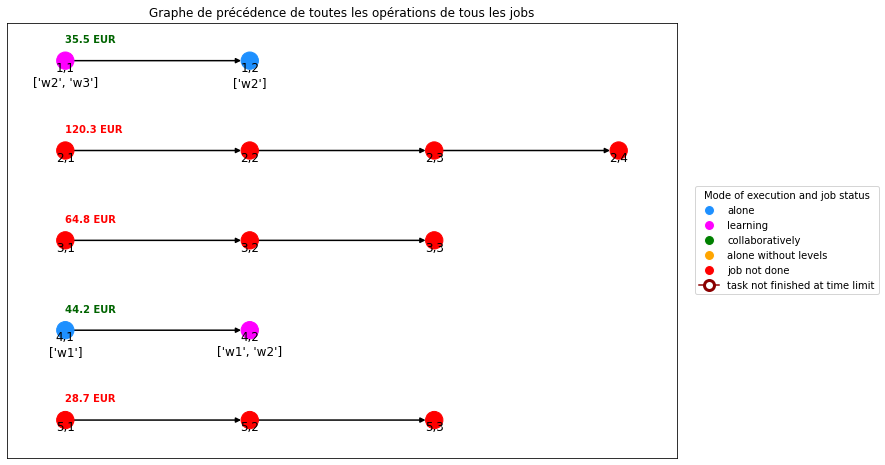

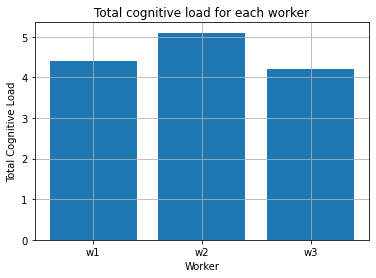

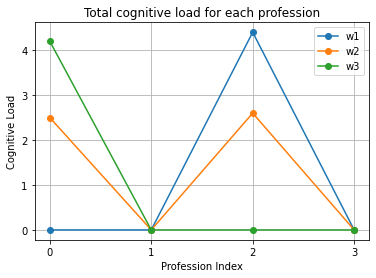

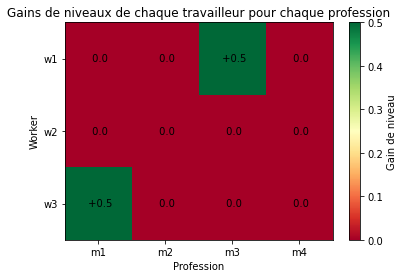

solution 1
benefit           79.78321
skills             0.00000
cognitive_load    -0.00000
Name: 1, dtype: float64


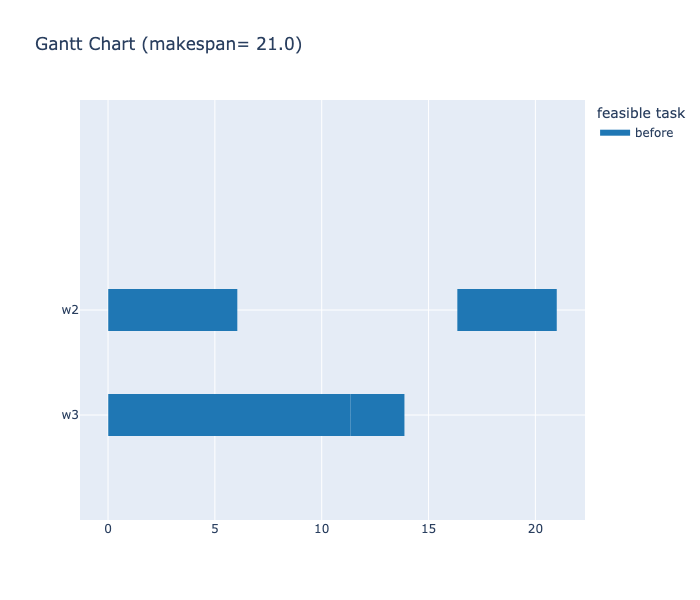

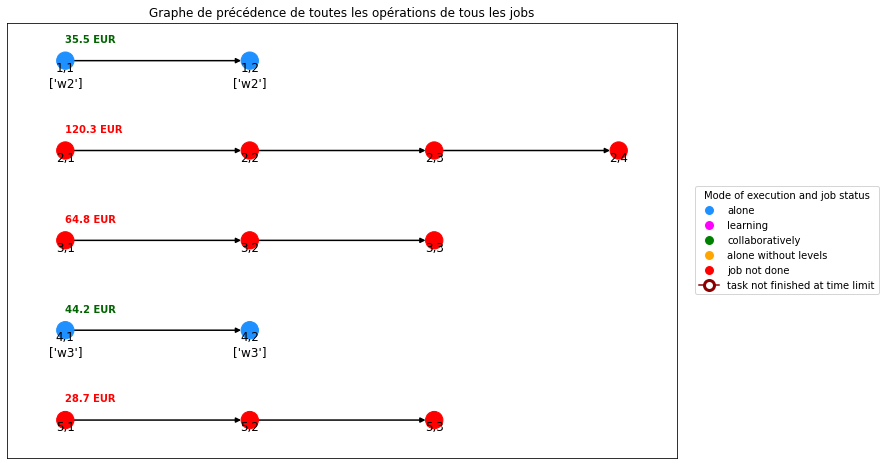

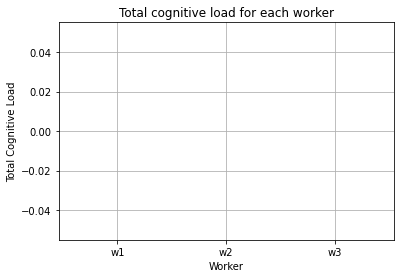

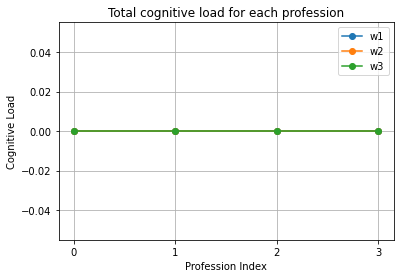

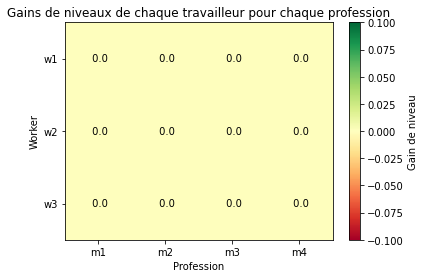

solution 2
benefit           35.54972
skills             3.00000
cognitive_load   -42.50000
Name: 2, dtype: float64


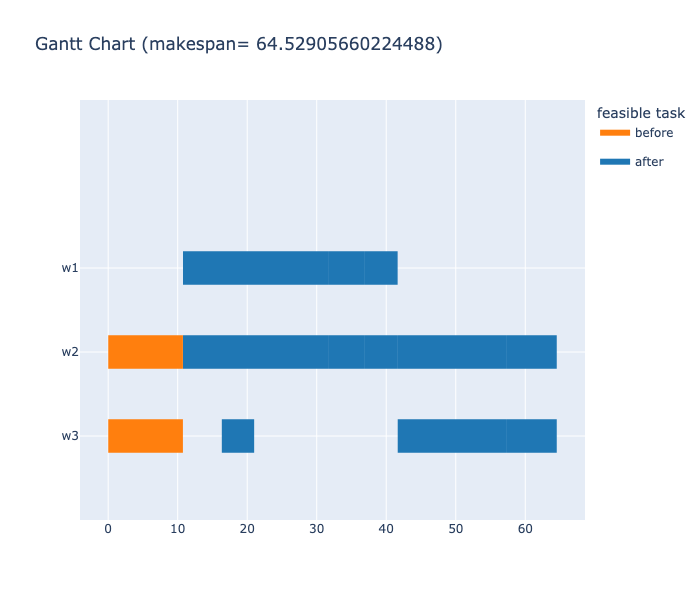

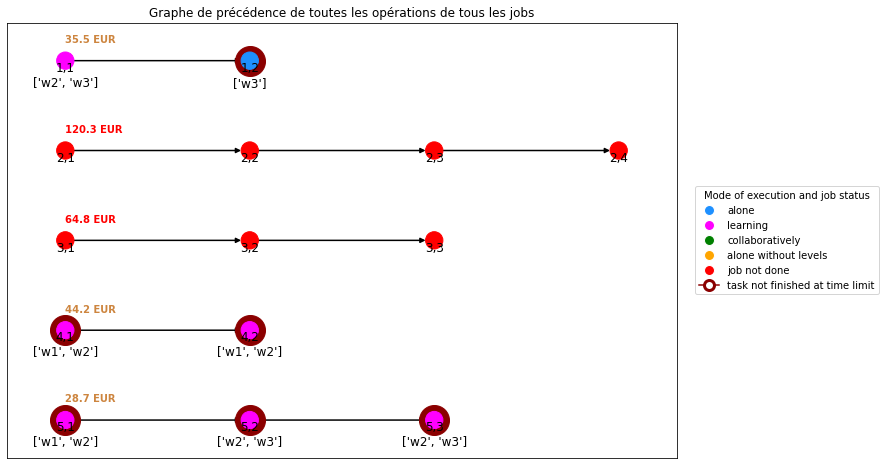

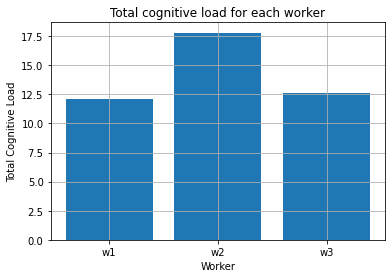

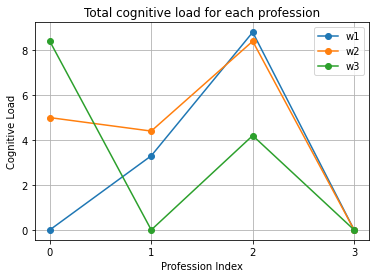

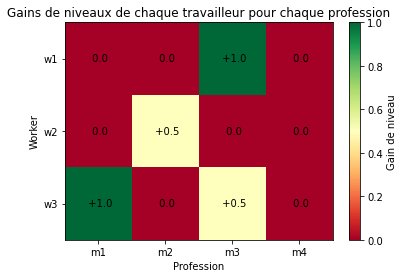

solution 10
benefit           79.78321
skills             1.50000
cognitive_load   -20.70000
Name: 10, dtype: float64


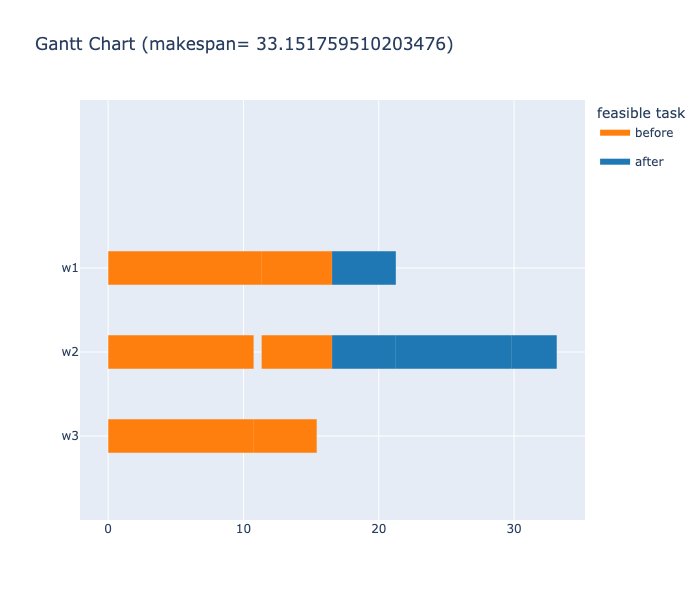

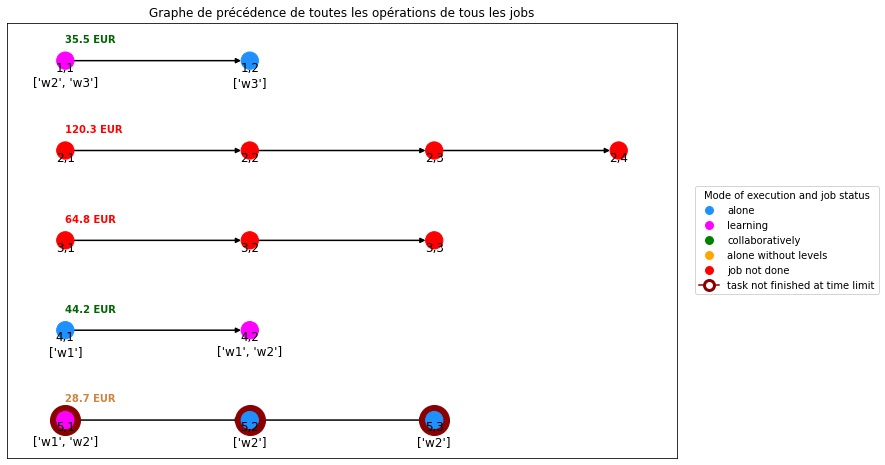

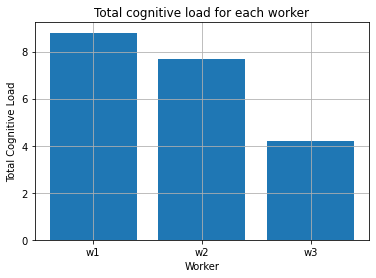

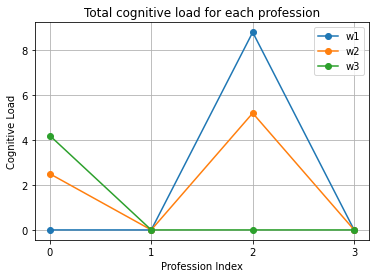

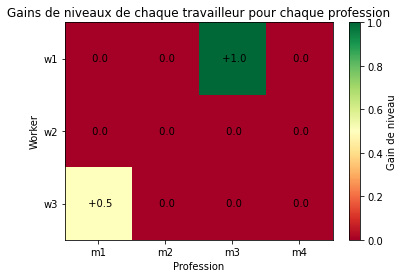

In [ ]:
for i in df_x_not_dominated.index:
    print(f"solution {i}")
    print(df_x_not_dominated.loc[i])

    df = scheduling_to_df(s[i], instance)
    gantt_chart(df, render="notebook", color=1, separate_little=True)
    visualization_after_scheduling(instance, s[i], df)

    bars_cognitive_load_total(s[i], instance)
    plot_cognitive_load_total(s[i], instance)
    resume_levels_workers(s[i], instance)
    print(df)
    print("----------------------------------------\n\n\n")
    

In [343]:
#plus de de detail sur la solution 2
s[2].job_done_before_limit, s[2].job_done

(array([1., 0., 0., 0., 0.]), array([1., 0., 0., 1., 1.]))

---

# #Maximiser différent critères sur les skills des workers

Soit $M$ la matrice de skills des workers, avec $M$ de dimension $n \times m$ où $n$ est le nombre de workers et $m$ est le nombre de corps de métier.

| | $m_1$ | $m_2$ | ... | $m_m$ |
|:-------- |:--------:|:----------:|:----------:| --------:|
|$w_1$|  | |  | |
|$w_2$|  | |  ||
|...|  | |  ||
|$w_n$|  | |  ||

- max $\sum M_{ij}$
- max min $M_{ij}$ $\rightarrow$ Souvent des valeurs à 0 pose problème
- $\forall i$: max min $M_{i\_} \rightarrow$ maximise le plus petit skill par worker
- $\forall j$: max min $M_{\_j} \rightarrow$ maximise le plus petit skill par métier

- Pour voir la différence il faut avoir beaucoup d'opération mais temps de calcul trop long, avec peu d'opération on ne voit pas la différence, critère d'agregation a utiliser avec les algorithmes génétiques